In [1]:
from google.colab import files
uploaded = files.upload()


Saving tobacco.csv to tobacco.csv


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


In [3]:
df = pd.read_csv("tobacco.csv")
df.head()


,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_produksi,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,0,TON,2016
1,2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,0,TON,2016
2,3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,46,TON,2016
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,1358,TON,2016
4,5,32,JAWA BARAT,3205,KABUPATEN GARUT,3597,TON,2016


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   243 non-null    int64 
 1   kode_provinsi        243 non-null    int64 
 2   nama_provinsi        243 non-null    object
 3   kode_kabupaten_kota  243 non-null    int64 
 4   nama_kabupaten_kota  243 non-null    object
 5   jumlah_produksi      243 non-null    int64 
 6   satuan               243 non-null    object
 7   tahun                243 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 15.3+ KB


In [11]:
y = df['jumlah_produksi']


In [12]:
X = df.drop(columns=[
    'jumlah_produksi',
    'nama_provinsi',
    'nama_kabupaten_kota',
    'satuan'
])


In [13]:
X.head()
y.head()


,jumlah_produksi
0,0
1,0
2,46
3,1358
4,3597


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [16]:
population_size = 30
generations = 100
mutation_rate = 0.1
num_features = X_train.shape[1]


In [17]:
population = np.random.randn(population_size, num_features)


In [18]:
def fitness(weights):
    y_pred = np.dot(X_train, weights)
    return mean_squared_error(y_train, y_pred)


In [19]:
for gen in range(generations):
    fitness_scores = np.array([fitness(ind) for ind in population])

    # Seleksi (ambil 10 terbaik)
    selected = population[np.argsort(fitness_scores)[:10]]

    offspring = []
    for i in range(0, len(selected), 2):
        parent1 = selected[i]
        parent2 = selected[(i+1) % len(selected)]

        crossover_point = np.random.randint(1, num_features)
        child = np.concatenate(
            (parent1[:crossover_point], parent2[crossover_point:])
        )
        offspring.append(child)

    offspring = np.array(offspring)

    # Mutasi
    mutation = mutation_rate * np.random.randn(*offspring.shape)
    population = np.vstack((selected, offspring + mutation))


In [20]:
best_weights = population[
    np.argmin([fitness(ind) for ind in population])
]


In [21]:
y_pred = np.dot(X_test, best_weights)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)


Mean Squared Error: 372904.7618833753


In [22]:
best_fitness_per_generation = []


In [23]:
for gen in range(generations):
    fitness_scores = np.array([fitness(ind) for ind in population])

    # Simpan fitness terbaik
    best_fitness = fitness_scores.min()
    best_fitness_per_generation.append(best_fitness)

    # Seleksi (10 terbaik)
    selected = population[np.argsort(fitness_scores)[:10]]

    offspring = []
    for i in range(0, len(selected), 2):
        parent1 = selected[i]
        parent2 = selected[(i+1) % len(selected)]

        crossover_point = np.random.randint(1, num_features)
        child = np.concatenate(
            (parent1[:crossover_point], parent2[crossover_point:])
        )
        offspring.append(child)

    offspring = np.array(offspring)

    # Mutasi
    mutation = mutation_rate * np.random.randn(*offspring.shape)
    population = np.vstack((selected, offspring + mutation))


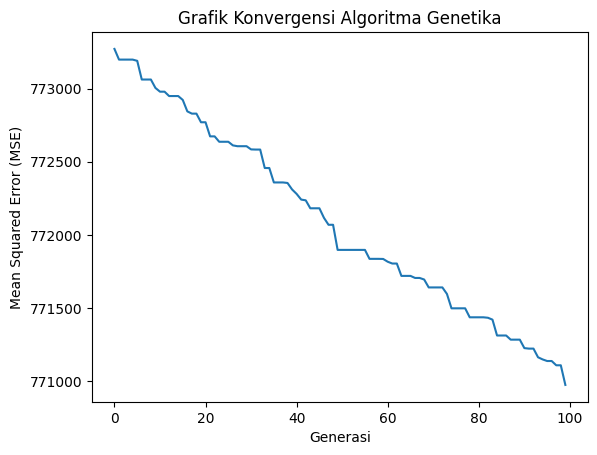

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(best_fitness_per_generation)
plt.xlabel("Generasi")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Grafik Konvergensi Algoritma Genetika")
plt.show()


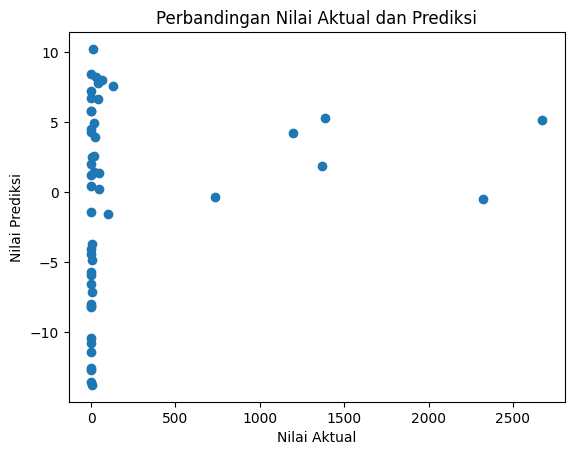

In [25]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Nilai Aktual dan Prediksi")
plt.show()
